## KNN 분류(K-Nearest Neighbors Classifier)

Iris 데이터셋을 활용해 데이터 스케일링부터 KNN 분류 모델 학습 및 평가까지 진행하는 코드이다.

[핵심 포인트 요약 (Key Takeaways)]                                                                      
 • 거리 기반 알고리즘: KNN은 데이터 간 유클리드 거리를 측정하므로 표준화(StandardScaler) 스케일링 필수   
  • 데이터 누수(Data Leakage) 방지: Train 데이터로만 스케일러를 학습(fit)하고, Test 데이터는 transform만 적용

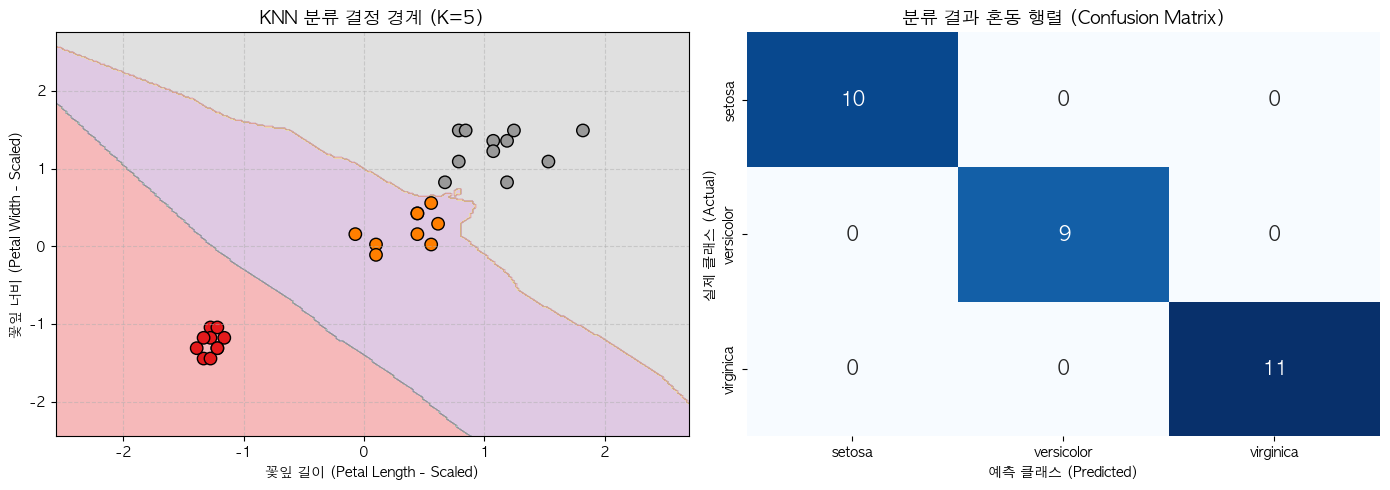

In [ ]:
# ============================================================================
# KNN(K-최근접 이웃)으로 붓꽃 품종 분류하기 + 결정 경계 시각화
# ============================================================================
# [이 코드가 하는 일]
#   꽃잎의 길이와 너비 2개만 보고 붓꽃 품종(3종)을 맞히는 모델을 만들고,
#   "어느 영역에 있으면 어떤 품종으로 판단하는지"를 색칠한 지도로 그린다.
#
# [KNN의 원리 한 줄]
#   새 데이터가 들어오면 가장 가까운 이웃 K개를 찾아, 그중 다수결로 분류한다.
# ============================================================================

import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix


# ---------------------------------------------------------------------------
# 0. 한글 폰트 설정
# ---------------------------------------------------------------------------
# matplotlib의 기본 폰트에는 한글 글리프가 없어서, 설정하지 않으면
# 그래프의 한글이 전부 네모(□□□)로 깨진다. OS마다 기본 한글 폰트가 다르므로 분기.
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"    # 윈도우: 맑은 고딕
elif os_name == "Darwin":                             # Darwin = macOS의 커널 이름
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"       # 리눅스 (별도 설치 필요)

# 한글 폰트로 바꾸면 마이너스 기호(−)가 깨지는 부작용이 생긴다.
# 유니코드 마이너스 대신 ASCII 하이픈을 쓰게 해서 방지.
plt.rcParams["axes.unicode_minus"] = False


# ---------------------------------------------------------------------------
# 1. 데이터 로드
# ---------------------------------------------------------------------------
iris = load_iris()

# iris.data는 (150, 4) 배열. 열 순서는 아래와 같다.
#   [0] sepal length (꽃받침 길이)
#   [1] sepal width  (꽃받침 너비)
#   [2] petal length (꽃잎 길이)     <- 이것과
#   [3] petal width  (꽃잎 너비)     <- 이것만 사용
#
# [:, 2:] = "모든 행, 2번 열부터 끝까지" -> 꽃잎 관련 2개 열만 남긴다.
# 4개를 다 쓰면 4차원이라 그림으로 못 그린다. 2개로 줄여야 x-y 평면에 그릴 수 있다.
# 꽃잎을 고른 이유: 품종 구분력이 꽃받침보다 훨씬 좋아서 경계가 깔끔하게 나온다.
X = iris.data[:, 2:]        # (150, 2)  입력 특성
y = iris.target             # (150,)    정답 라벨 — 0=setosa, 1=versicolor, 2=virginica


# ---------------------------------------------------------------------------
# 2. 학습용 / 테스트용 분리
# ---------------------------------------------------------------------------
# 모델을 학습시킨 데이터로 평가하면 "외운 것"을 맞히는 셈이라 의미가 없다.
# 그래서 처음 보는 데이터를 따로 떼어 둔다.
#   test_size=0.2   -> 150개 중 30개를 평가용으로 (120 / 30으로 나뉨)
#   random_state=42 -> 난수 고정. 이게 없으면 실행할 때마다 결과가 달라져 비교가 불가능.
#
# 참고: 분류 문제에서는 stratify=y 를 넣어 클래스 비율을 유지하는 것이 안전하다.
#       (여기서는 안 넣었지만 우연히 10 / 9 / 11로 고르게 나뉘었다)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ---------------------------------------------------------------------------
# 3. 피처 스케일링 (표준화)
# ---------------------------------------------------------------------------
# KNN은 '거리'로 이웃을 찾는 알고리즘이다. 특성마다 단위나 범위가 다르면
# 값이 큰 특성 하나가 거리 계산을 지배해버려서, 나머지 특성이 무시된다.
# 표준화로 모든 특성을 평균 0, 표준편차 1로 맞춰 발언권을 동등하게 만든다.
scaler = StandardScaler()

# ★ fit_transform 과 transform 을 구분하는 것이 핵심 ★
#   fit_transform : 평균·표준편차를 "계산"하고 그 기준으로 변환   -> train에만
#   transform     : 이미 계산해 둔 기준을 "적용"만                -> test에는 이것만
# 만약 test에도 fit을 하면 테스트 데이터의 통계가 학습에 새어 들어간다(= 데이터 누수).
# 그러면 평가 점수가 실제보다 좋게 나와서 진짜 성능을 알 수 없게 된다.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ---------------------------------------------------------------------------
# 4. KNN 모델 생성 및 학습
# ---------------------------------------------------------------------------
#   n_neighbors=5     : 가장 가까운 이웃 5개를 보고 다수결. K가 이 모델의 핵심 손잡이.
#                       K가 작으면(1) 잡음에 민감해 경계가 들쭉날쭉 -> 과적합
#                       K가 크면       경계가 뭉뚝해지고 소수 클래스를 놓침 -> 과소적합
#                       보통 홀수로 잡는다. 짝수면 동점이 날 수 있어서.
#   metric='euclidean': 거리를 자로 잰 직선거리로 계산.
#                       (기본값 metric='minkowski', p=2 와 완전히 동일하다.
#                        명시해 두면 읽는 사람이 헷갈리지 않아서 좋다)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# KNN은 '게으른 학습(lazy learning)' 알고리즘이다.
# fit()이 하는 일은 사실상 데이터를 통째로 기억해 두는 것뿐이고,
# 실제 계산은 predict() 시점에 "그때그때 거리를 재면서" 일어난다.
# 그래서 학습은 순식간이지만 예측이 상대적으로 느리다.
knn.fit(X_train_scaled, y_train)


# ---------------------------------------------------------------------------
# 5. 예측
# ---------------------------------------------------------------------------
# 테스트 데이터 30개 각각에 대해, 학습 데이터 120개와의 거리를 전부 계산 ->
# 가까운 5개를 골라 -> 그 5개의 라벨 중 가장 많은 것으로 예측한다.
y_pred = knn.predict(X_test_scaled)


# ---------------------------------------------------------------------------
# 6. 시각화 — 왼쪽에 결정 경계, 오른쪽에 혼동 행렬
# ---------------------------------------------------------------------------
# 1행 2열 배치. axes는 [왼쪽 축, 오른쪽 축] 배열이 된다.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ===== [좌측] 결정 경계 (Decision Boundary) =====
# 아이디어: 화면 전체를 촘촘한 격자로 덮고, 격자점 하나하나를 모델에 물어본 뒤
#          "여기는 무슨 품종?"의 답에 따라 색을 칠한다. 결과적으로 모델이
#          공간을 어떻게 나눠 보고 있는지가 지도처럼 드러난다.

# (1) 격자의 범위 정하기 — 데이터 양옆으로 1씩 여유를 둬서 점이 테두리에 붙지 않게 한다
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

# (2) 격자 만들기 — 0.02 간격으로 촘촘하게
#     meshgrid는 x좌표 배열과 y좌표 배열을 받아 '모든 조합'의 좌표판 2장을 만든다.
#     여기서는 261 x 264 = 68,904개의 격자점이 생긴다. 간격을 줄이면 더 매끄럽지만
#     그만큼 predict 호출이 늘어 느려진다. (0.02는 부드러움과 속도의 무난한 타협점)
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# (3) 격자점 전부를 모델에 넣어 예측
#     ravel()   : (261, 264) 2차원 판을 (68904,) 1차원으로 쭉 편다
#     np.c_[a,b]: 두 1차원 배열을 열 방향으로 붙여 (68904, 2) 좌표 목록을 만든다
#                 -> 모델이 원하는 "샘플 68904개 × 특성 2개" 형태가 된다
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# (4) 예측 결과를 다시 격자 모양으로 되돌린다 — 그래야 지도처럼 그릴 수 있다
Z = Z.reshape(xx.shape)      # (68904,) -> (261, 264)

# (5) 배경 색칠. contourf는 원래 등고선을 채우는 함수인데,
#     Z가 0/1/2 정수라서 결과적으로 클래스별 영역이 구획된 색면으로 나온다.
#     alpha=0.3으로 옅게 깔아야 위에 찍을 점들이 잘 보인다.
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# (6) 그 위에 테스트 데이터의 '실제 정답'을 점으로 찍는다.
#     점의 색(실제 품종)과 배경색(모델의 판단)이 같으면 맞힌 것,
#     다르면 틀린 것 -> 오분류를 눈으로 바로 찾을 수 있다.
#       c=y_test        : 점 색을 실제 라벨에 따라 지정
#       edgecolors='k'  : 검은 테두리. 배경색과 겹쳐도 점이 구분된다
#       s=80            : 점 크기
scatter = axes[0].scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1],
    c=y_test, cmap=plt.cm.Set1, edgecolors='k', s=80
)

axes[0].set_title("KNN 분류 결정 경계 (K=5)", fontsize=13)
# 축 이름에 'Scaled'를 붙인 이유: 표준화된 값이라 실제 cm 단위가 아니기 때문.
# (0이 평균, 1이 표준편차 1만큼 떨어진 위치를 뜻한다)
axes[0].set_xlabel("꽃잎 길이 (Petal Length - Scaled)")
axes[0].set_ylabel("꽃잎 너비 (Petal Width - Scaled)")
axes[0].grid(True, linestyle="--", alpha=0.5)


# ===== [우측] 혼동 행렬 (Confusion Matrix) =====
# 실제 클래스(행) × 예측 클래스(열)의 교차표.
# 대각선 = 맞힌 개수, 대각선 밖 = 틀린 개수.
# 정확도 숫자 하나보다 "무엇을 무엇으로 착각했는지"를 알 수 있어 훨씬 유용하다.
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,                        # 칸 안에 숫자 표시
    fmt='d',                           # 정수 형식 (안 쓰면 1.2e+01 같이 나온다)
    cmap='Blues',                      # 값이 클수록 진한 파랑
    xticklabels=iris.target_names,     # 0/1/2 대신 실제 품종 이름을 축에
    yticklabels=iris.target_names,
    ax=axes[1],                        # 오른쪽 축에 그리라는 지정
    cbar=False,                        # 색상 막대 제거 (3x3 표에는 불필요)
    annot_kws={"size": 14}             # 숫자 폰트 크기
)
axes[1].set_title("분류 결과 혼동 행렬 (Confusion Matrix)", fontsize=13)
axes[1].set_xlabel("예측 클래스 (Predicted)")
axes[1].set_ylabel("실제 클래스 (Actual)")


# tight_layout(): 제목과 축 이름이 서로 겹치지 않게 여백을 자동 조정
plt.tight_layout()
plt.show()

RMSE (평균 제곱근 오차): 0.1002
R² Score (결정계수): 0.9791


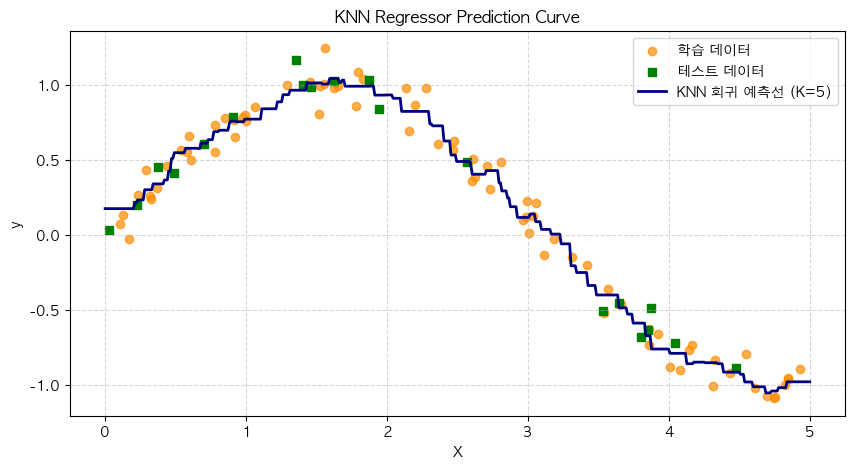

In [ ]:
# ============================================================================
# KNN 회귀(KNeighborsRegressor)로 비선형 곡선 학습하기
# ============================================================================
# [분류 KNN과 무엇이 다른가]
#   분류: 가까운 이웃 K개의 라벨을 보고 → 다수결      (투표)
#   회귀: 가까운 이웃 K개의 y값을 보고  → 평균        (평균)
#   원리는 같고 마지막 집계 방식만 다르다.

# [이 코드의 목적]
#   sin 곡선처럼 직선으로는 절대 표현 못 하는 관계를,
#   KNN이 "수식 없이 이웃만 보고" 어떻게 따라잡는지 확인한다.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ⚠️ 아래 그래프 라벨에 한글을 쓰는데 폰트 설정이 빠져 있다 → 전부 □□□로 깨진다.
#    앞선 KNN 분류 코드에는 있었는데 여기서는 누락됐다. 이 두 줄을 추가할 것.
import platform
os_name = platform.system()
plt.rcParams["font.family"] = ("Malgun Gothic" if os_name == "Windows"
                               else "AppleGothic" if os_name == "Darwin"
                               else "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트 적용 시 마이너스 기호 깨짐 방지


# ---------------------------------------------------------------------------
# 1. 인공 데이터 생성 — "정답을 아는" 데이터를 만든다
# ---------------------------------------------------------------------------
# 실제 데이터는 진짜 관계식을 모르지만, 여기서는 sin(x)라는 정답을 우리가 정해 놓고
# 거기에 잡음을 섞는다. 그래야 "모델이 진짜 관계를 얼마나 찾아냈나"를 채점할 수 있다.
np.random.seed(42)   # 난수 고정 — 실행할 때마다 같은 데이터가 나오게

# np.random.rand(100, 1) : 0~1 사이 난수 100개, (100, 1) 2차원 배열
#   × 5              → 0~5 범위로 확장
#   np.sort(..., axis=0) → 오름차순 정렬. 예측선을 그릴 때 점들이 x순으로 이어지도록.
#   (2차원인 이유: sklearn은 X를 항상 "샘플 × 특성" 2차원으로 받는다. 특성 1개라도 (100,1))
X = np.sort(5 * np.random.rand(100, 1), axis=0)

# y = sin(X) + 잡음
#   .ravel()  : (100, 1) → (100,) 1차원으로 편다. y는 1차원이어야 한다.
#   np.random.normal(0, 0.1, 100) : 평균 0, 표준편차 0.1인 정규분포 잡음
#     → 현실 데이터의 측정 오차를 흉내낸 것. 이 0.1이 나중에 성능의 한계선이 된다.
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])


# ---------------------------------------------------------------------------
# 2. 학습용 / 테스트용 분리 (8:2)
# ---------------------------------------------------------------------------
# 회귀 문제이므로 stratify는 쓰지 않는다 (클래스가 없으니 비율을 맞출 대상이 없다).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)   # 학습 80개 / 테스트 20개


# ---------------------------------------------------------------------------
# 3. 피처 스케일링
# ---------------------------------------------------------------------------
# KNN은 거리로 이웃을 찾으므로, 단위가 다른 특성이 섞이면 큰 값이 거리를 지배한다.
# 그래서 원칙적으로 스케일링은 필수다.
#
# 다만 ★이 코드에서는 특성이 1개라 실제 예측이 전혀 바뀌지 않는다★
#   표준화는 (x - 평균) / 표준편차 — 단조 선형변환이라 모든 거리가 같은 배율로 줄 뿐,
#   "누가 더 가까운가"의 순서는 그대로다 → 이웃 K개가 동일 → 예측도 동일.
#   (실제로 스케일링 유무의 예측값이 완전히 일치하는 것을 확인했다)
# 그래도 남겨두는 이유: 특성이 2개 이상으로 늘어나는 순간 반드시 필요해지고,
#                     습관으로 굳혀 두는 편이 안전하기 때문.
scaler = StandardScaler()

# ★ fit은 train에만, test에는 transform만 ★
#   fit_transform : 평균·표준편차를 계산하고 변환
#   transform     : 이미 계산된 기준을 적용만
#   test에 fit하면 테스트 데이터의 통계가 새어 들어간다(데이터 누수).
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ---------------------------------------------------------------------------
# 4. KNN 회귀 모델 학습
# ---------------------------------------------------------------------------
#   n_neighbors=5 : 가까운 이웃 5개의 y값을 평균내어 예측
#   weights       : 이웃들의 의견을 어떻게 합칠지
#       'uniform'  → 5개 모두 동등하게 1/5씩 (기본값)
#       'distance' → 가까울수록 큰 가중치(1/거리). 경계가 부드러워지고
#                    학습점에서는 그 점의 값에 정확히 붙는다
#   metric='euclidean' : 직선거리.
#       기본값 metric='minkowski', p=2 와 완전히 같다. 명시해두면 읽기 편할 뿐.
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='euclidean')

# KNN은 '게으른 학습(lazy learning)'이다.
# fit()은 데이터를 저장만 하고, 진짜 계산은 predict()에서 거리를 재며 일어난다.
# → 학습은 순식간, 예측은 상대적으로 느림. (선형회귀와 정반대)
knn_reg.fit(X_train_scaled, y_train)


# ---------------------------------------------------------------------------
# 5. 예측 및 성능 평가
# ---------------------------------------------------------------------------
y_pred = knn_reg.predict(X_test_scaled)

# RMSE: MSE에 제곱근을 씌운 값. y와 단위가 같아져 "평균 이만큼 틀린다"로 읽힌다.
#       (MSE는 단위가 y의 제곱이라 값 자체를 해석하기 어렵다)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²: 모델이 y의 변동을 얼마나 설명하는지. 1=완벽, 0=평균만 찍은 수준, 음수도 가능.
r2 = r2_score(y_test, y_pred)

print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")   # → 0.1002
print(f"R² Score (결정계수): {r2:.4f}")          # → 0.9791
# ★ 해석 포인트 ★
#   우리가 넣은 잡음의 표준편차가 0.1이었다. RMSE가 0.1002라는 건
#   "잡음만큼만 틀리고 있다" = 이론상 도달 가능한 한계에 사실상 도달했다는 뜻.
#   여기서 더 낮추려는 건 잡음을 외우는 것(과적합)이지 실력 향상이 아니다.


# ---------------------------------------------------------------------------
# 6. 예측 곡선 시각화
# ---------------------------------------------------------------------------
# 아이디어: 0~5 구간을 촘촘히 훑으면서 "여기서는 얼마로 예측해?"를 500번 물어보고,
#          그 답을 선으로 이으면 모델이 학습한 함수의 모양이 드러난다.

# linspace(0, 5, 500) : 0부터 5까지 균등하게 500개
# reshape(-1, 1)      : (500,) → (500, 1). sklearn 입력 형태를 맞추기 위함.
#                       -1은 "나머지는 알아서 계산하라"는 뜻.
X_grid = np.linspace(0, 5, 500).reshape(-1, 1)

# ★ 격자에도 반드시 같은 scaler를 적용해야 한다 ★
#   모델은 표준화된 공간에서 학습했으므로, 원본 스케일 값을 그대로 넣으면 엉뚱한 답이 나온다.
#   여기서도 fit이 아니라 transform이다 (train에서 배운 기준을 그대로 적용).
X_grid_scaled = scaler.transform(X_grid)
y_grid_pred = knn_reg.predict(X_grid_scaled)

plt.figure(figsize=(10, 5))

# 학습 데이터: 모델이 본 점들
plt.scatter(X_train, y_train, color='darkorange', label='학습 데이터', alpha=0.7)

# 테스트 데이터: 모델이 못 본 점들. marker='s'(square)로 모양을 달리해 구분
plt.scatter(X_test, y_test, color='green', label='테스트 데이터', marker='s')

# 예측선. ★그림에서 가장 주목할 점: 이 선은 매끄러운 곡선이 아니라 '계단'이다★
#   x가 조금 움직여도 이웃 5개 집합이 그대로면 평균값이 안 바뀌기 때문.
#   이웃 하나가 교체되는 순간 값이 툭 튀면서 계단 모서리가 생긴다.
#   (실제로 격자 500점에 대한 예측값은 75종류뿐 = 75단 계단)
plt.plot(X_grid, y_grid_pred, color='navy', label='KNN 회귀 예측선 (K=5)', linewidth=2)

# ※ 축의 x값에 X_grid(원본 스케일)를 쓴 것이 맞다.
#   예측은 표준화 공간에서 했지만, 보여줄 때는 사람이 읽을 수 있는 원래 단위로.

plt.title("KNN Regressor Prediction Curve")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()